In [16]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm

In [6]:
#base simples de clientes

np.random.seed(0) # deixa os resultados iguais toda vez

idades = np.random.randint(18, 71, 1000) # idades aleatorias
renda = np.random.normal(3500, 900, 1000) # cria rendas em uma distribuicao normal
gastos = renda * 0.18 + np.random.normal(100, 120, 1000) # cria gastos com relacao simples com a renda
comprou = np.random.random(1000) < 0.4 # compras com probabilidade fixa

dados = pd.DataFrame({
    "idade": idades,
    "renda": renda,
    "gastos": gastos,
    "comprou": comprou
}) # junta os dados em uma tabela

dados["faixa_idade"] = (dados["idade"] // 10) * 10 # separa as idades por decada

dados.head()

,idade,renda,gastos,comprou,faixa_idade
0,62,1784.746513,475.154456,False,60
1,65,3753.839894,801.772855,False,60
2,18,1441.124067,464.808194,False,10
3,21,3003.673287,672.469098,True,20
4,21,4586.858599,877.675065,False,20


In [9]:
media_gastos = np.mean(dados["gastos"]) 
mediana_gastos = np.median(dados["gastos"])
moda_idade = stats.mode(dados["idade"]) # calcula a idade que mais aparece

print("media dos gastos:", media_gastos)
print("mediana dos gastos:", mediana_gastos)
print("moda das idades:", moda_idade)

media dos gastos: 724.5829124153242
mediana dos gastos: 725.3722528680393
moda das idades: ModeResult(mode=np.int32(21), count=np.int64(30))


In [11]:
desvio_gastos = dados["gastos"].std() # dp dos gastos
variancia_gastos = dados["gastos"].var() # variancia dos gastos
percentil_25 = np.percentile(dados["gastos"], 25) # percentil 25
percentil_50 = np.percentile(dados["gastos"], 50) # percentil 50
percentil_90 = np.percentile(dados["gastos"], 90) # percentil 90

print("desvio padrao:", desvio_gastos)
print("variancia:", variancia_gastos)
print("percentil 25:", percentil_25)
print("percentil 50:", percentil_50)
print("percentil 90:", percentil_90)

desvio padrao: 197.89012254991468
variancia: 39160.500602820255
percentil 25: 593.740785333211
percentil 50: 725.3722528680393
percentil 90: 986.6655957537535


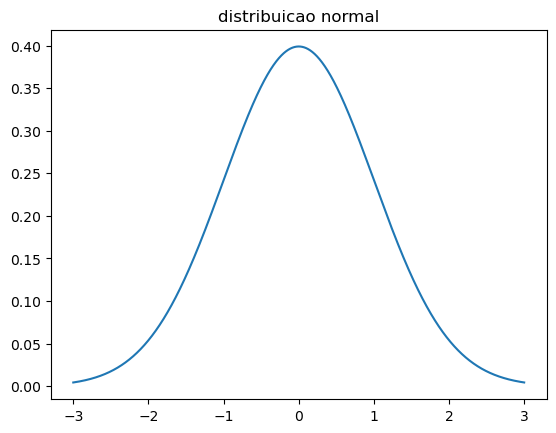

In [12]:
x = np.arange(-3, 3, 0.001) # cria valores para o eixo x
plt.plot(x, norm.pdf(x)) # plota a funcao de densidade normal
plt.title("distribuicao normal")
plt.show()

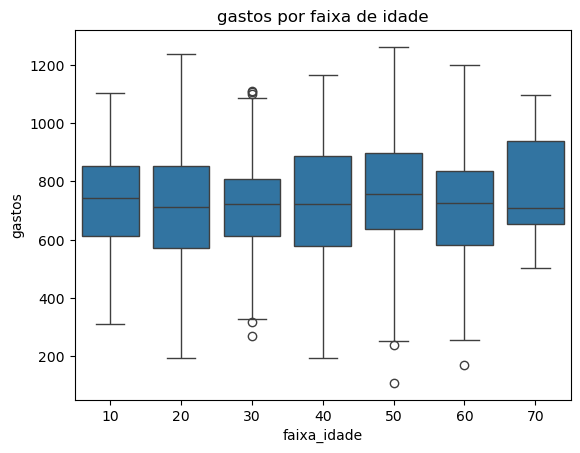

In [13]:
sns.boxplot(x="faixa_idade", y="gastos", data=dados) # compara os gastos por faixa de idade
plt.title("gastos por faixa de idade")
plt.show()

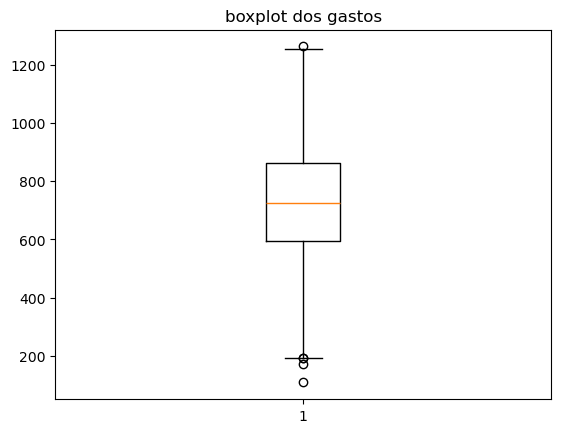

In [14]:
plt.boxplot(dados["gastos"]) # cria um boxplot para observar valores extremos
plt.title("boxplot dos gastos")
plt.show()

In [17]:
assimetria = stats.skew(dados["gastos"]) # calcula se os dados estao mais puxados para algum lado
curtose = stats.kurtosis(dados["gastos"]) # formato da distribuicao

print("assimetria:", assimetria)
print("curtose:", curtose)

assimetria: -0.07013177646434912
curtose: -0.232898728568252


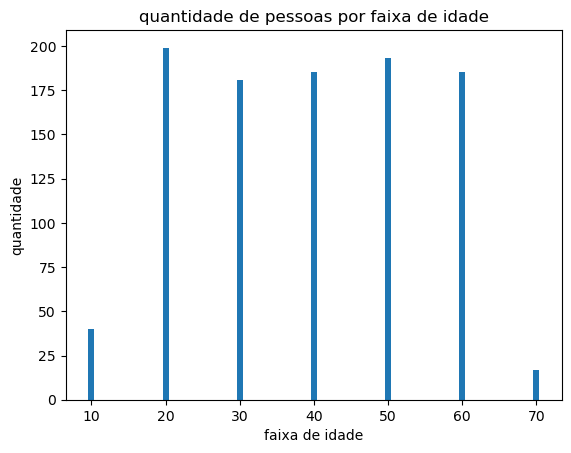

In [18]:
contagem_faixa = dados["faixa_idade"].value_counts().sort_index() # conta quantas pessoas tem em cada faixa de idade

plt.bar(contagem_faixa.index, contagem_faixa.values) # cria um grafico de barras simples
plt.xlabel("faixa de idade")
plt.ylabel("quantidade")
plt.title("quantidade de pessoas por faixa de idade")
plt.show()